In [4]:
import numpy as np

import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

import jaxopt

import tinygp

%matplotlib inline
import matplotlib.pyplot as plt

In [5]:
title = "# Gaussian random fields and processes"
# Print title and setup TeX defs for both KaTeX and MathJax
import bayesian_stats_course_tools
bayesian_stats_course_tools.misc.display_markdown_and_setup_tex(title)

import matplotlib.style
matplotlib.style.use("bayesian_stats_course_tools.light")

# Gaussian random fields and processes

<!-- Define LaTeX macros -->
$\def\E{\operatorname{E}}$
$\def\Var{\operatorname{Var}}$
$\def\Cov{\operatorname{Cov}}$
$\def\dd{\mathrm{d}}$
$\def\ee{\mathrm{e}}$
$\def\Norm{\mathcal{N}}$
$\def\Uniform{\mathcal{U}}$
$\def\GP{\mathcal{GP}}$

<!-- MathJax needs them to be defined again for the non-inline environment -->
$$\def\E{\operatorname{E}}$$
$$\def\Var{\operatorname{Var}}$$
$$\def\Cov{\operatorname{Cov}}$$
$$\def\dd{\mathrm{d}}$$
$$\def\ee{\mathrm{e}}$$
$$\def\Norm{\mathcal{N}}$$
$$\def\Uniform{\mathcal{U}}$$
$$\def\GP{\mathcal{GP}}$$

## Gaussian processes

We have seen Gaussian random variables and their (finite-dimensional) multivariate form.

This can be further generalised to Gaussian random fields (or processes, both mean the same thing), which are (infinite-dimensional) distributions over functions.

In a Gaussian process, at any finite set of points $x_1, \dots, x_n$, the values $y_1,\dots, y_n$ are jointly Gaussian distributed:
$$
    (y_1, \dots, y_n) \sim \Norm\left((\mu_{x_1},\dots,\mu_{x_n}), \Sigma_{x_1,\dots,x_n}\right)\,.
$$


As a whole, a Gaussian process is a distribution over _functions_ $f(x)=y$:
$$
    f\sim\GP(\mu, \Sigma) \,,
$$
where $\mu(x)$ and $\Sigma(x, x')$ are functions of the positions $x$.



This is a very flexible and powerful way to specify functions. 

Because of its probabilistic nature, it allows sampling and getting uncertainty estimates as well.

Helpful resources on Gaussian processes:
- The standard reference book: http://gaussianprocess.org/gpml/chapters/
- In-depth explanation and discussion of some of the possible pitfalls: https://betanalpha.github.io/assets/case_studies/gaussian_processes.html
- Nice intuitive explanation and visualisations: https://distill.pub/2019/visual-exploration-gaussian-processes/

Gaussian processes can come in handy when we want to model data for which we do not have a physical model. 

For example, poorly understood observational or measurement effects. 


In this case, we might have a mean function $\mu(x)$ that provides a physical model for the contributions to the data we understand (and care about), while we use a Gaussian process to model the poorly-understood residuals.



For this reason, Gaussian processes often assume that the mean is zero, since we can always subtract a mean function from the data:
$$
    f_\mathrm{residual}\sim\GP(0, \Sigma) \quad \leftrightarrow \quad  f_\mathrm{residual} + \mu \sim\GP(\mu, \Sigma)
$$


The data is often homogeneous (translation-invariant, stationary), that is, the covariance does not depend on the absolute position but only on their differences:
$$
    \Sigma(x, x') = \Sigma(x - x') \,.
$$

If the data is furthermore isotropic (rotation-invariant), the covariance only depends on the norm of the difference in the positions:
$$
    \Sigma(x, x') = \Sigma(\vert x - x'\vert) \,.
$$

In the context of Gaussian processes, the covariance function is also called the _kernel_ $k(x, x') = \Sigma(x, x')$.

This is the main modelling choice of a Gaussian process. 



A common choice is the exponential squared or radial basis function kernel:
$$
    k(x, x') = \mathrm{e}^{-\frac{1}{2}\frac{\Vert x - x'\Vert^2}{\ell^2}}
$$
The parameter of the kernel is its length-scale $\ell$: larger $\ell$ mean points further apart are more correlated.



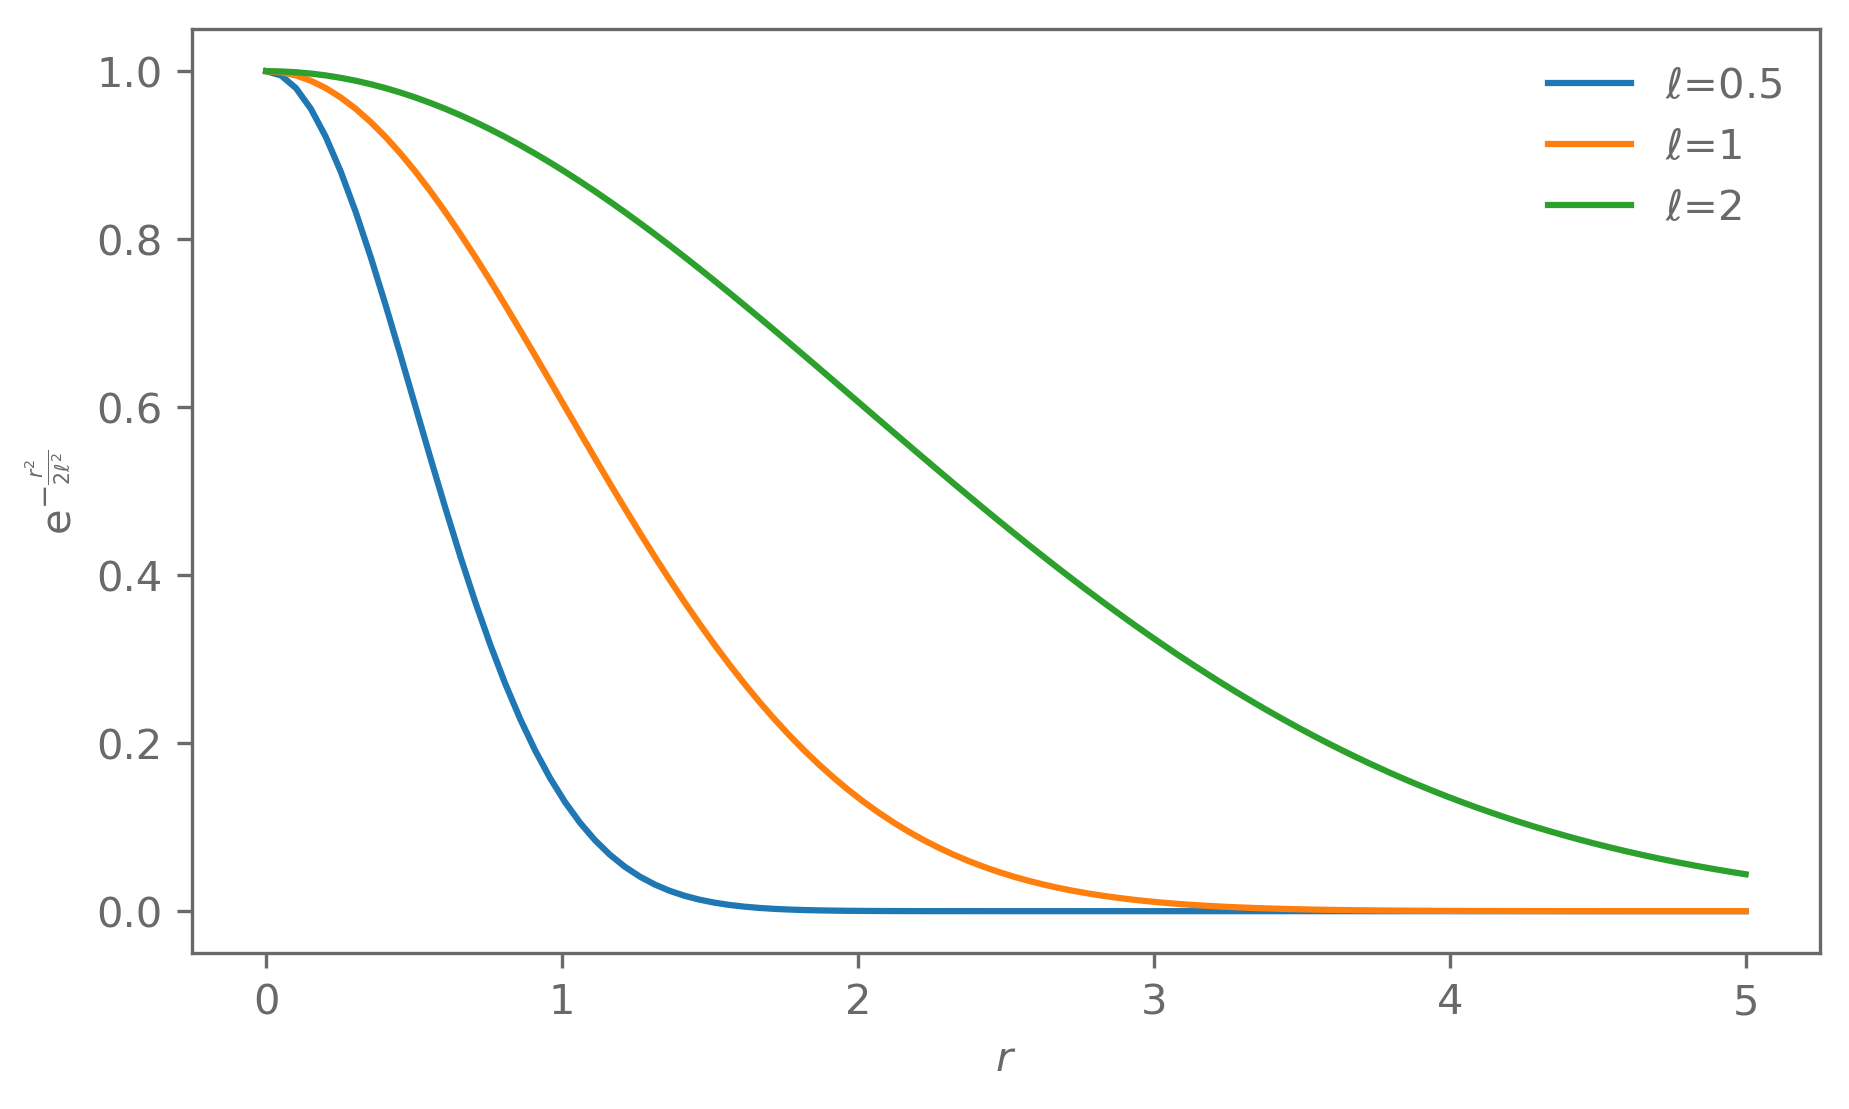

In [6]:
kernel = tinygp.kernels.ExpSquared(scale=2.0)

for l in [0.5, 1, 2]:
    kernel = tinygp.kernels.ExpSquared(scale=l)
    x = jnp.linspace(0, 5, 100)
    plt.plot(x, kernel(X1=jnp.array([0.0]), X2=x)[0], label=f"$\\ell$={l}")

plt.legend()
plt.xlabel(r"$r$")
_ = plt.ylabel(r"$\mathrm{e}^{-\frac{r^2}{2\ell^2}}$")

Kernels can be added and multiplied, for more flexible modelling of the correlation structure.

For example, scaling the exponential squared kernel allows us to change the overall variance of the distribution over functions:
$$
    k(x, x') = \sigma^2 \mathrm{e}^{-\frac{1}{2}\frac{\Vert x - x'\Vert^2}{\ell^2}}
$$

To implement the Gaussian process, we use the `tinygp` package:

In [7]:
import tinygp

random_key, main_key = jax.random.split(jax.random.PRNGKey(42))

# A exponential squared kernel with length scale 2 and scaled by
# an amplitude 1.3^2
kernel = 1.3**2 * tinygp.kernels.ExpSquared(scale=2.0)

x = jnp.linspace(0, 5, 100)
# The Gaussian process is evaluated at a set of points x and
# depends on the kernel. 
gp = tinygp.GaussianProcess(kernel, x)

# We can now draw function samples (evaluated at x) from the GP
gp_prior_samples = gp.sample(key=random_key, shape=(8,))

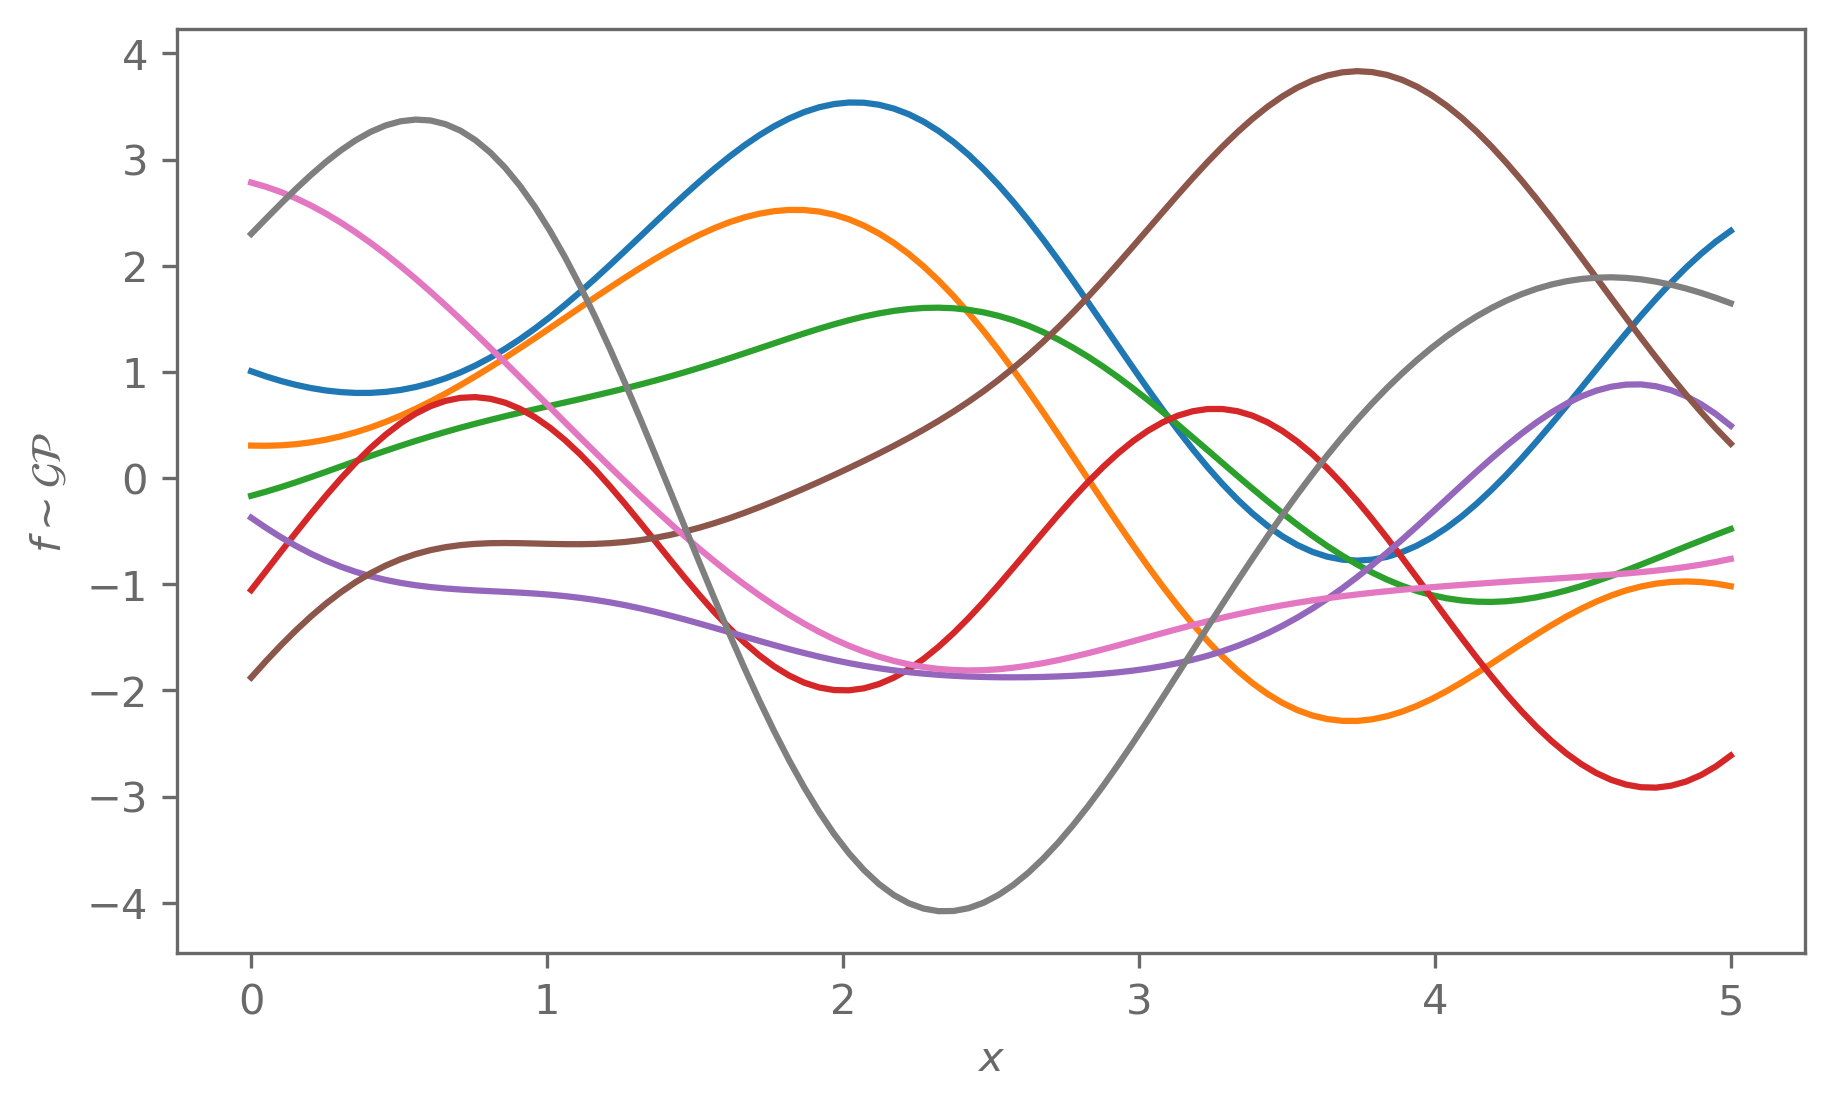

In [63]:
plt.plot(x, gp_prior_samples.T)
plt.xlabel("$x$")
plt.ylabel(r"$f\sim \mathcal{GP}$");

Different length scales and amplitudes affect the distribution of functions the Gaussian process samples:

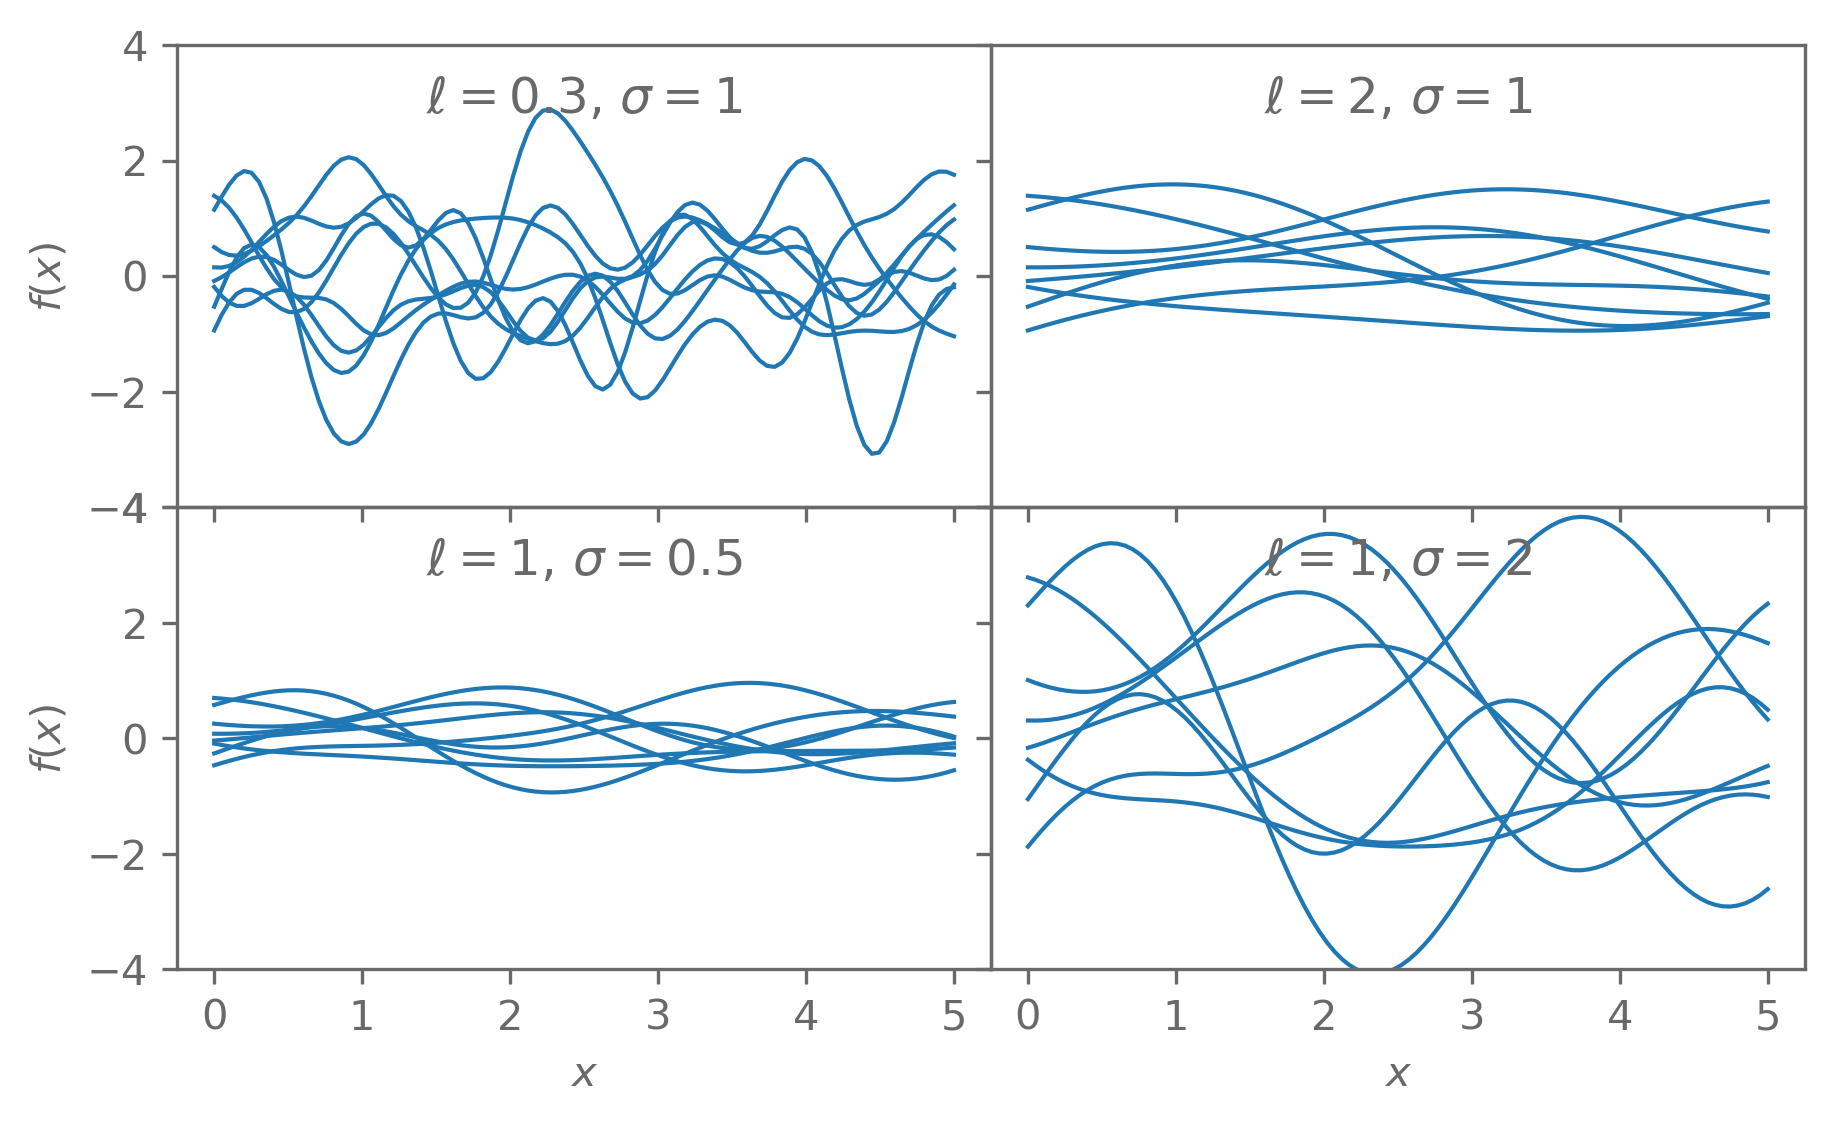

In [9]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)
fig.subplots_adjust(hspace=0, wspace=0)

x = jnp.linspace(0, 5, 100)

for ax, (l, sigma) in zip(axs.flat, [(0.3, 1), (2, 1), (1, 0.5), (1, 2)]):
    kernel = sigma**2 * tinygp.kernels.ExpSquared(scale=l)
    gp = tinygp.GaussianProcess(kernel, x)

    gp_prior_samples = gp.sample(key=random_key, shape=(8,))
    ax.plot(x, gp_prior_samples.T, c="C0", lw=1)
    ax.set_title(f"$\\ell=${l}, $\\sigma=${sigma}", y=0.8)

ax.set_ylim(-4, 4)
[a[0].set_ylabel("$f(x)$") for a in axs]
[a.set_xlabel("$x$") for a in axs[-1]];

What is actually happening here under the hood?

The kernel $k(x, x')$ specifies the covariance between input positions $x$ and $x'$.

To draw a sample function $f$, evaluated at some points $x_i$, we draw from a multivariate Gaussian distribution with covariance matrix
$$
    \Sigma_{ij} = k(x_i, x_j) \,.
$$

In [10]:
kernel = tinygp.kernels.ExpSquared(scale=1.0)

x = jnp.linspace(0, 5, 100)
k_matrix = kernel(x, x)

# Need to add a small component to the diagonal to make it numerically stable
k_matrix += 1e-6*jnp.eye(x.size)

# Draw correlated samples by multiplying iid standard normals with the 
# Cholesky decomposition of the covariance matrix
L = jnp.linalg.cholesky(k_matrix)
samples = L @ jax.random.normal(key=random_key, shape=(x.size, 5))

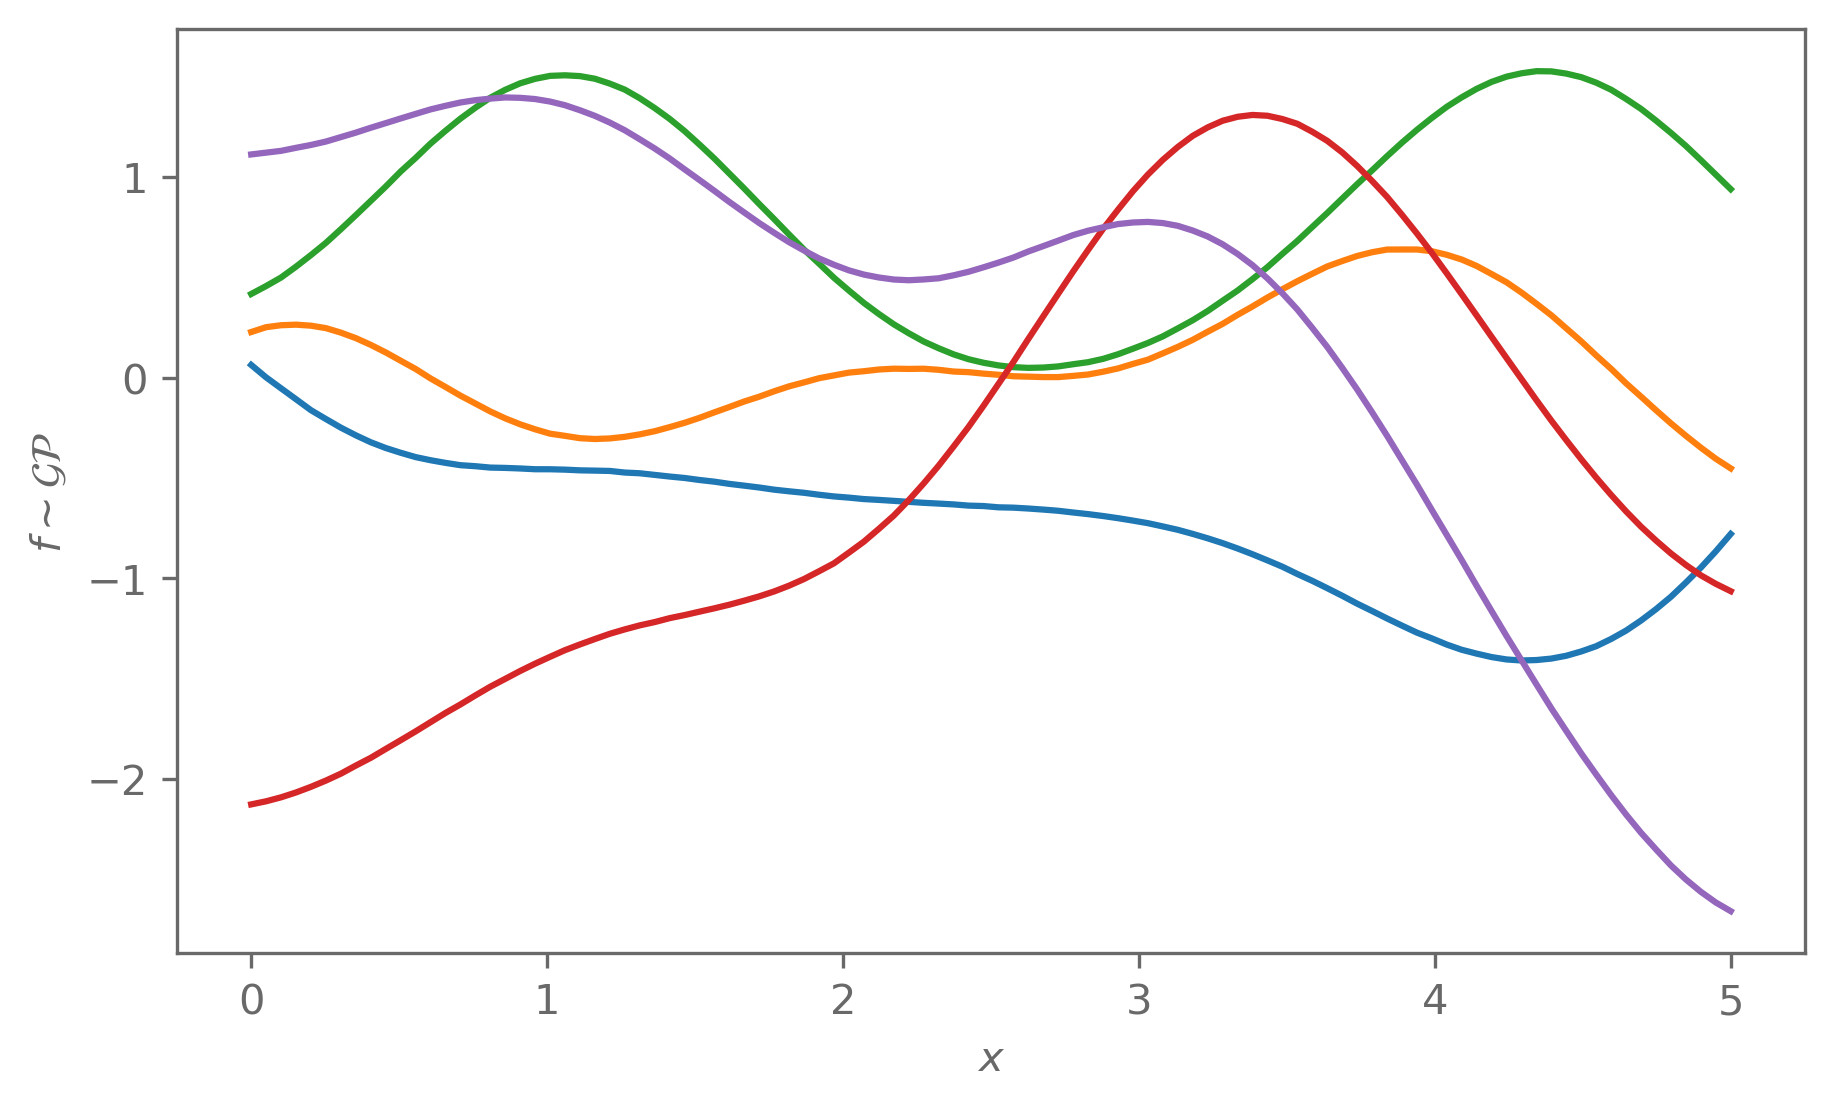

In [11]:
plt.plot(x, samples)
plt.xlabel("$x$")
plt.ylabel(r"$f\sim \mathcal{GP}$");

So far we only used the Gaussian process to draw samples of functions, without relating it to any specific data. 

In other words, these were samples from some prior over functions.



One key advantage of Gaussian processes is that we can easily condition them on observations.

Given a set of observed function values $f_i=f(x_i)$ at positions $x_i$, we can get the distribution of function values $f_j^*$ at some other set of positions $x^*_j$.


We first note that the joint distribution of $\vec f = (f_1, \dots, f_n)^T$ and $\vec f^* = (f_1^*, \dots, f_n^*)^T$ is again a multivariate Gaussian:
$$
    \begin{pmatrix}
        \vec f\\
        \vec f^*
    \end{pmatrix} \sim \Norm\left(
        \begin{pmatrix}
            \vec\mu\\
            \vec\mu^*
        \end{pmatrix}, 
        \begin{pmatrix}
            \Sigma_{xx} & \Sigma_{xx^*}\\
            \Sigma_{xx^*}^T & \Sigma_{x^*x^*}
        \end{pmatrix}
    \right)\,.
$$
The means and covariances are those of the Gaussian process:
\begin{align*}
    \vec\mu &= (\mu(x_1), \dots, \mu(x_n))^T \\
    \vec\mu^* &= (\mu(x^*_1), \dots, \mu(x^*_n))^T \\
    \Sigma_{xx} &= k(\vec x, \vec x) \\
    \Sigma_{xx^*} &= k(\vec x, \vec x^*) \\
    \Sigma_{x^*x^*} &= k(\vec x^*, \vec x^*)
\end{align*}



Because we are dealing with Gaussian distributions, we can use the fact that there is an exact expression for their conditional distributions:

$$
    \vec f^* | \vec f \sim \Norm\left( \vec\mu_{x^*|x}, \Sigma_{x^*|x}\right)
$$

$$
     \vec\mu_{x^*|x} = \vec\mu^* + \Sigma_{x^*x} \Sigma_{xx}^{-1}(\vec f - \vec\mu)
$$
$$
     \Sigma_{x^*|x} = \Sigma_{x^*x^*} - \Sigma_{x^*x} \Sigma_{xx}^{-1}\Sigma_{xx^*}
$$

This ability to make predictions at new positions based on observations becomes especially useful when the likelihood is Gaussian.

Let us say that our data $y_i$ at positions $x_i$ have a Gaussian likelihood with mean $f(x_i)$ and variance $\sigma_y^2$:
$$
    y_i \sim \Norm(f(x_i), \sigma_y^2)\,.
$$


If $f$ is a Gaussian process with mean $\mu$ and kernel $k$, $f \sim \GP(\mu, k)$, then 
$$
    y_i \sim \Norm(\mu(x_i), \Sigma_{x_i x_i})
$$
with
$$
    \Sigma_{x_i x_j} = k(x_i, x_j) + \delta_{ij}\sigma_y^2 \,.
$$

For a Gaussian likelihood, the posterior over functions $f^*$ is again a Gaussian process and we can use the same conditioning machinery:
$$
    \vec f^* | \vec y \sim \Norm\left( \vec\mu_{x^*|x}, \Sigma_{x^*|x}\right) \,.
$$



The covariance at the observations $\Sigma_{xx}$ now includes the observational uncertainty $\sigma_y$ on the diagonal:
$$
    \Sigma_{x_i x_j} = k(x_i, x_j) + \delta_{ij}\sigma_y^2 \,.
$$

The diagonal observational uncertainty $\delta_{ij}\sigma_y$ can be generalised to a full noise matrix $\Sigma^y_{ij}$.

Let us see how this works on some synthetic data:

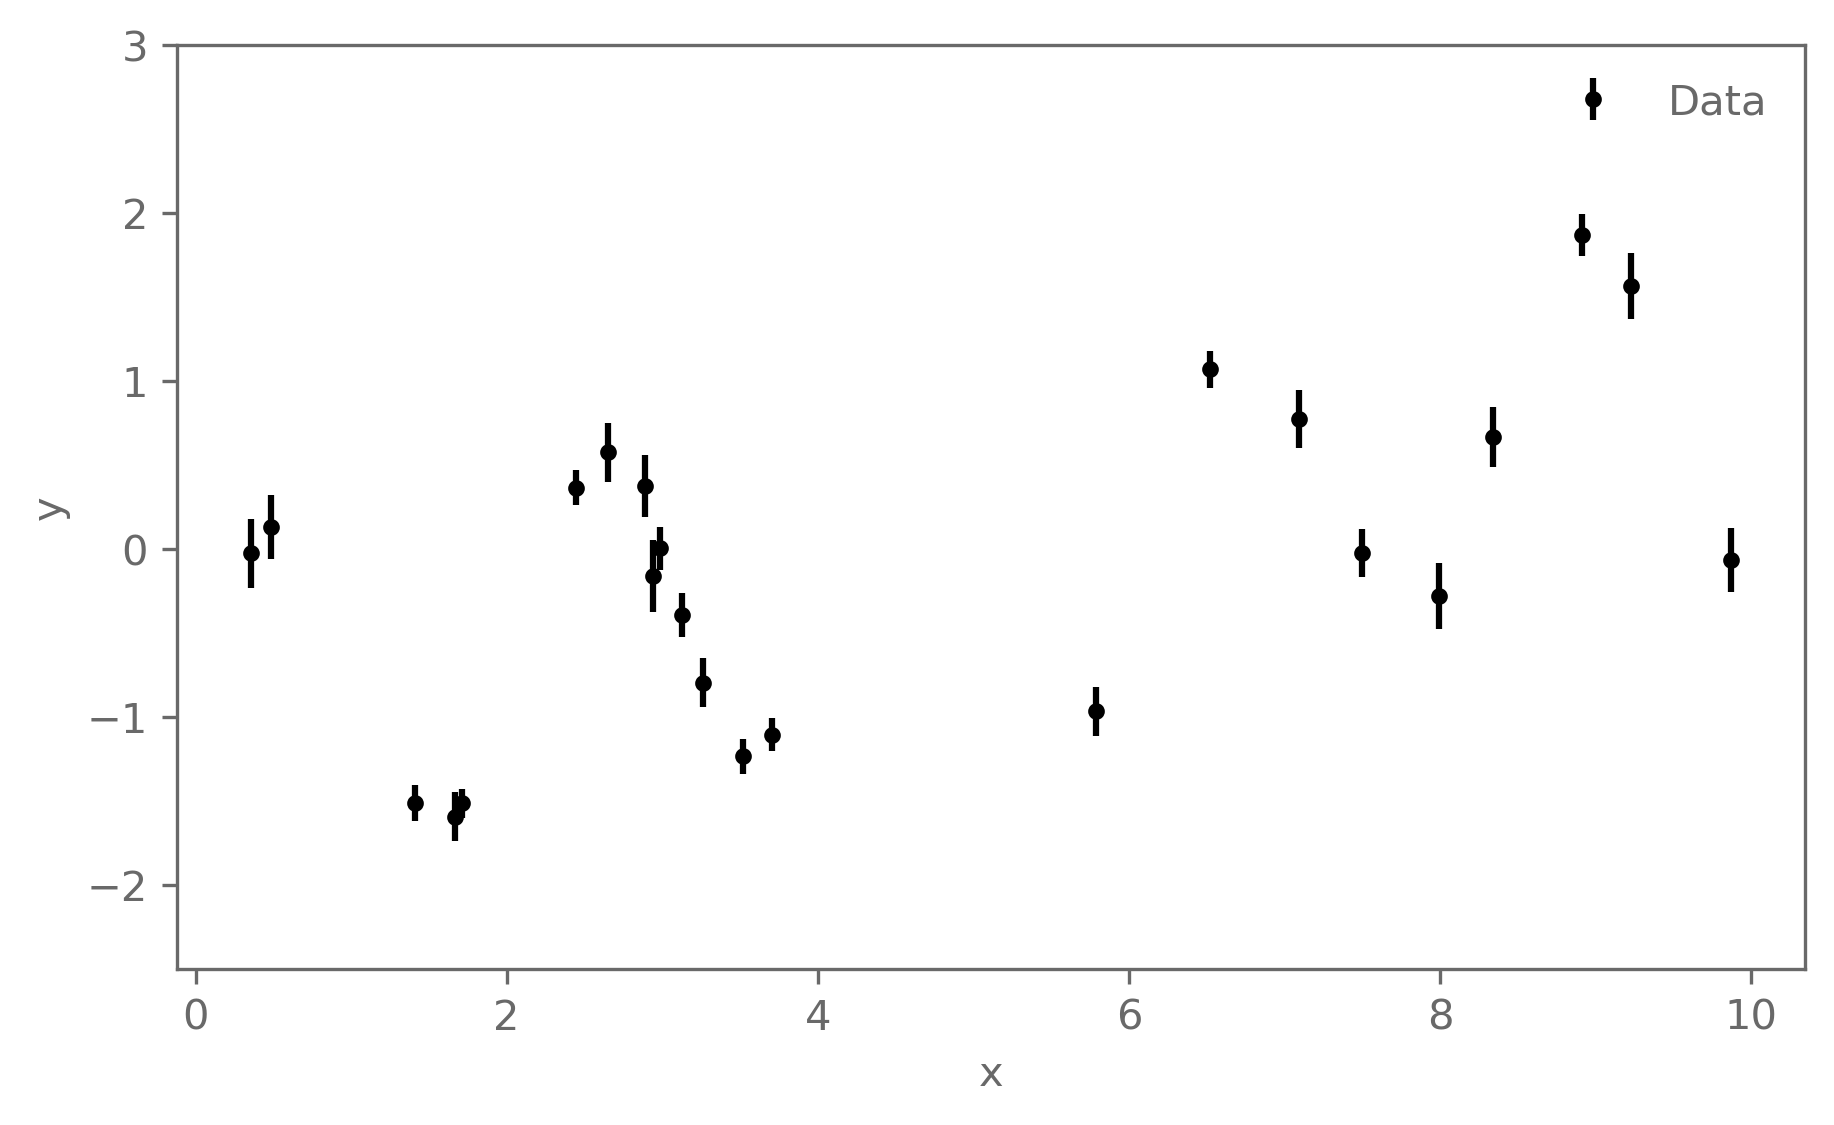

In [12]:
def f_true(x):
    return 0.2 * (x - 5) + np.sin(3 * x)

def generate_data():
    random = np.random.default_rng(42)

    n_1, n_2 = 14, 9

    x_obs = np.sort(
        np.append(
            random.uniform(0, 3.8, n_1),
            random.uniform(5.5, 10, n_2),
        )
    )
    y_err = random.uniform(0.08, 0.22, len(x_obs))
    y_obs = (
        f_true(x_obs) + y_err * random.normal(size=len(x_obs))
    )
    return x_obs, y_obs, y_err


def plot_data(x_obs, y_obs, y_err, plot_f_true=False):
    x_pred = np.linspace(-2, 17, 500)
    f_pred_true = f_true(x_pred)

    fig, ax = plt.subplots()

    if plot_f_true:
        ax.plot(x_pred, f_pred_true, "k", lw=1.5, alpha=0.3, label="True f(x)")
    ax.errorbar(x_obs, y_obs, yerr=y_err, fmt=".k", capsize=0, label="Data")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_ylim(-2.5, 3)
    ax.legend()

    return fig, ax

x_obs, y_obs, y_err = generate_data()

_ = plot_data(x_obs, y_obs, y_err)

We are given observations `y_obs` with uncertainties `y_err` at positions `x_obs`. 

To start, we try a simple exponential square kernel and set up the GP in `tinygp`.

In [13]:
l = 1.5
sigma = 1

kernel = sigma**2 * tinygp.kernels.ExpSquared(scale=l)

gp = tinygp.GaussianProcess(
    kernel, x_obs, diag=y_err**2,
)

Now comes the key part: we condition the GP on the observed data `y_obs` and make predictions at some other positions.

In [14]:
# Define the points where we want the GP to make prediction
x_pred = np.linspace(-2, 17, 100)

# Now we can condition the GP on the observed values y_obs and get predictions
# at x_pred. This is again a GP
conditioned_gp = gp.condition(y=y_obs, X_test=x_pred).gp

# Extract the mean and variance of the prediction (we get the uncertainty) 
# for free!
mu, std = conditioned_gp.loc, jnp.sqrt(conditioned_gp.variance)

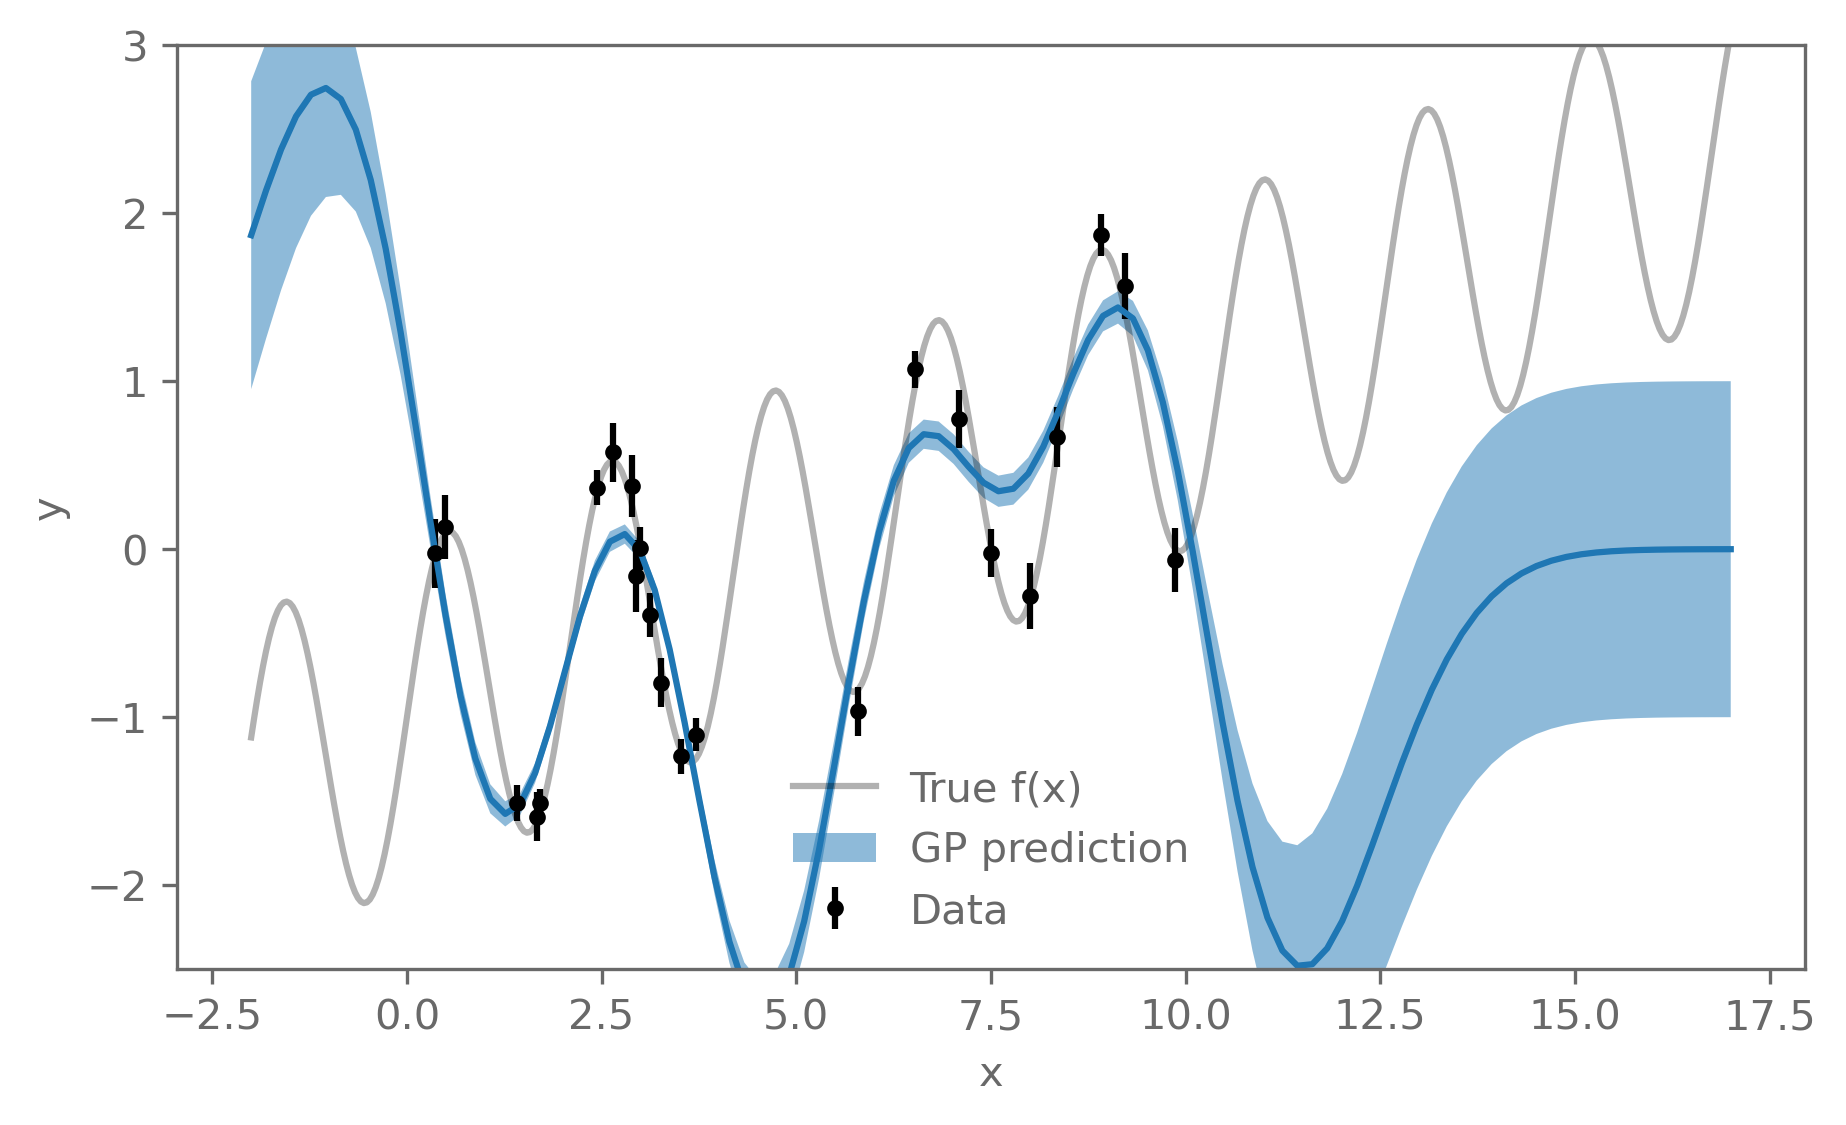

In [16]:
fig, ax = plot_data(x_obs, y_obs, y_err, plot_f_true=True)

ax.plot(x_pred, mu)
ax.fill_between(x_pred, mu-std, mu+std, alpha=0.5, label="GP prediction")
ax.legend();

Not terrible, not great.

We can evaluate the probability of the observed data `y_obs` under the GP model:

In [17]:
gp.log_probability(y=y_obs)

Array(-122.66108481, dtype=float64)

By maximising this probability (the likelihood), we can find values for the parameters of the kernel that describe the data better.

In [18]:
def build_gp(params, x_obs, y_err):
    l = jnp.exp(params["log_l"])
    sigma = jnp.exp(params["log_sigma"])
    kernel = sigma**2 * tinygp.kernels.ExpSquared(scale=l)

    gp = tinygp.GaussianProcess(
        kernel, x_obs, diag=y_err**2,
    )
    return gp

# For the minimisation, we need the negative log likelihood
def neg_log_likelihood(params, x_obs, y_obs, y_err):
    gp = build_gp(params, x_obs, y_err)
    return -gp.log_probability(y=y_obs)

In [21]:
params_init = dict(
    log_l = jnp.log(1),
    log_sigma = jnp.log(1)
)
print(f"Initial negative log likelihood: "
      f"{neg_log_likelihood(params_init, x_obs, y_obs, y_err)}")

# Find the maximum of the likelihood
solver = jaxopt.ScipyMinimize(fun=neg_log_likelihood)
result = solver.run(params_init, x_obs=x_obs, y_obs=y_obs, y_err=y_err)

print(f"Final negative log likelihood: {result.state.fun_val}")
print(f"Parameter values: {result.params}")

Initial negative log likelihood: 37.63546421761678
Final negative log likelihood: 12.760563475310185
Parameter values: {'log_l': Array(-0.50627298, dtype=float64), 'log_sigma': Array(0.0405664, dtype=float64)}


In [22]:
# Build the GP with the fitted parameters
gp = build_gp(result.params, x_obs=x_obs, y_err=y_err)

conditioned_gp = gp.condition(y=y_obs, X_test=x_pred).gp
mu, std = conditioned_gp.loc, jnp.sqrt(conditioned_gp.variance)

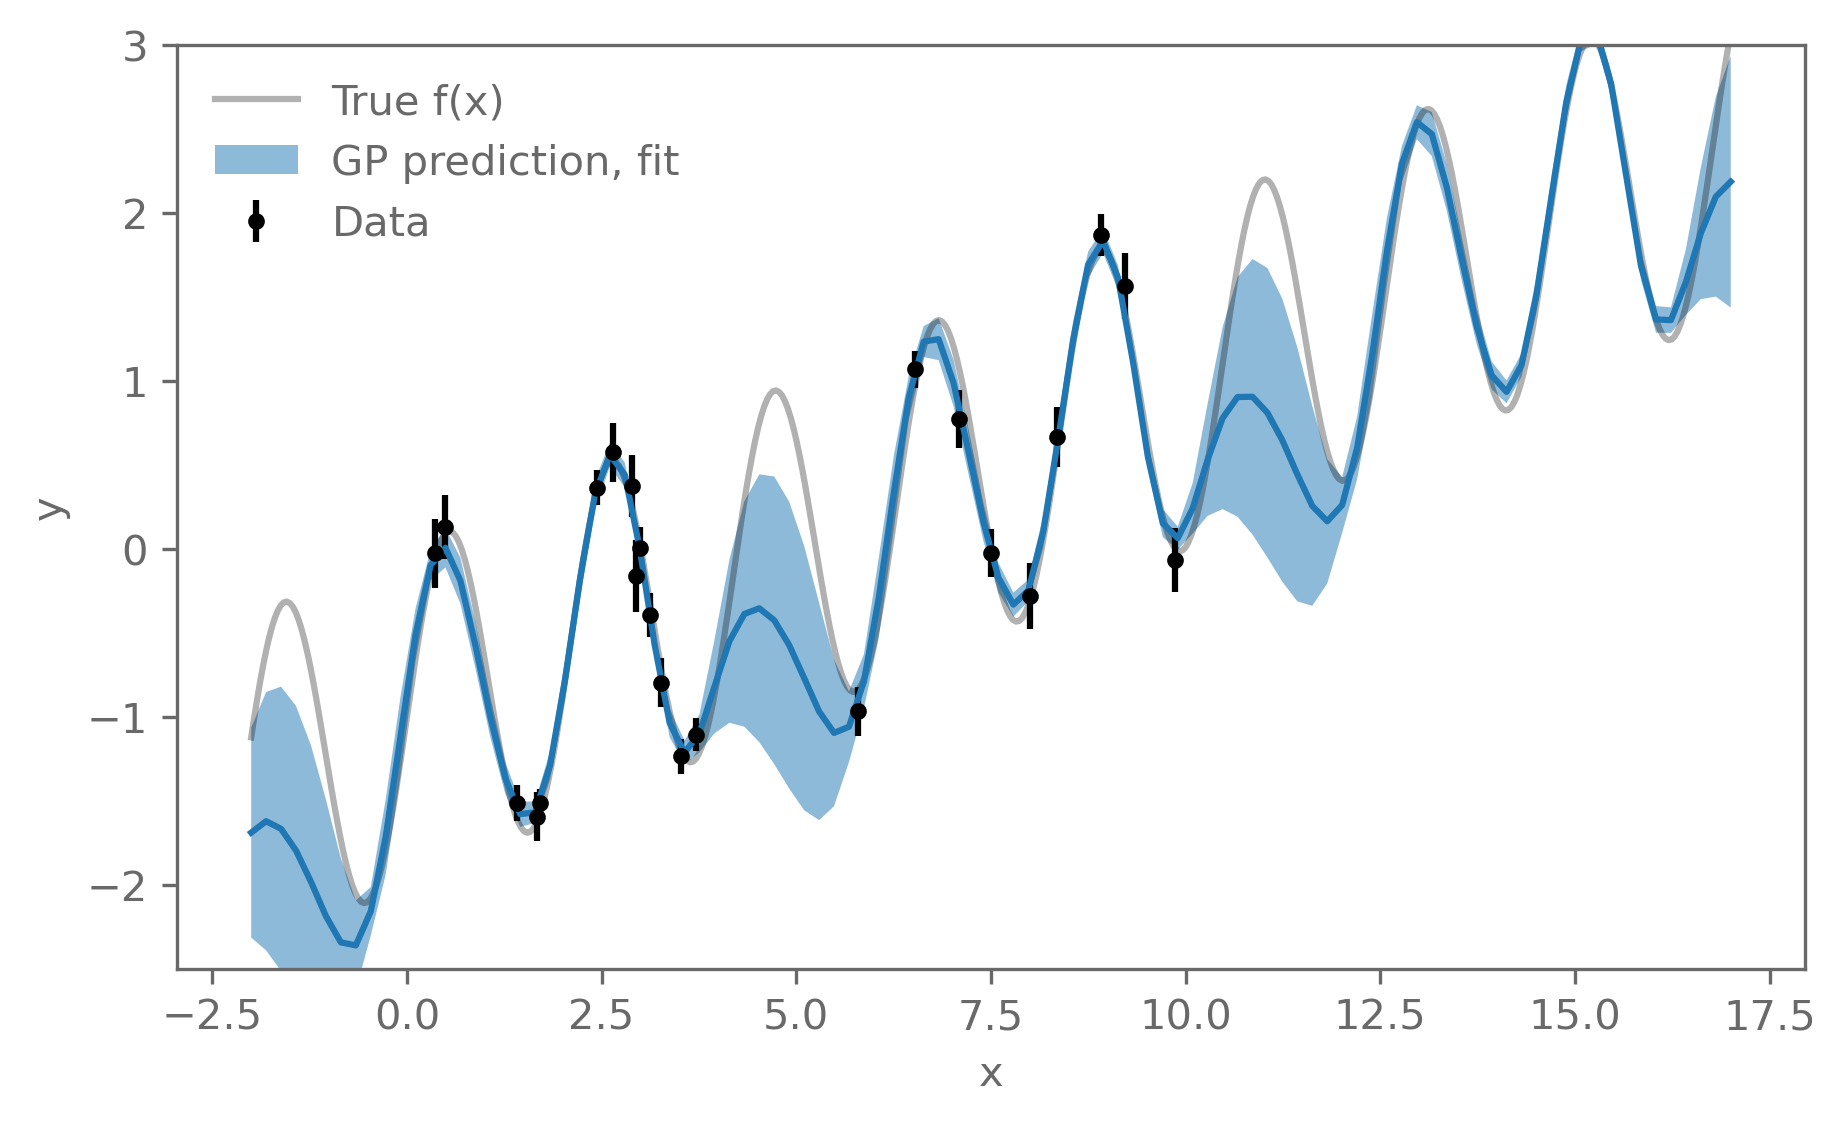

In [64]:
fig, ax = plot_data(x_obs, y_obs, y_err, plot_f_true=True)

ax.plot(x_pred, mu)
ax.fill_between(x_pred, mu-std, mu+std, alpha=0.5, label="GP prediction, fit")
ax.legend();

Better, but the extrapolation is still poor.

To do better, we could try a different kernel. 



Here we try a kernel that can account for a periodic signal.

We also add a simple linear model for the mean.

In [24]:
def build_gp(params, x_obs, y_err):
    period = params["period"]
    gamma = jnp.exp(params["log_gamma"])
    sigma = jnp.exp(params["log_sigma"])
    slope = params["slope"]
    kernel = sigma**2 * tinygp.kernels.ExpSineSquared(scale=period, gamma=gamma)
    
    mean_offset = params["mean"]
    mean_func = lambda x: mean_offset + slope*x

    gp = tinygp.GaussianProcess(
        kernel, x_obs, diag=y_err**2, mean=mean_func
    )
    return gp

In [31]:
def neg_log_likelihood(params, x_obs, y_obs, y_err):
    gp = build_gp(params, x_obs, y_err)
    return -gp.log_probability(y=y_obs)

params_init = dict(
    period = 6.0,
    log_gamma = jnp.log(1),
    log_sigma = jnp.log(1),
    slope=0.0,
    mean=0.0
)

print(f"Initial negative log likelihood: {neg_log_likelihood(params_init, x_obs=x_obs, y_obs=y_obs, y_err=y_err)}")
solver = jaxopt.ScipyMinimize(fun=neg_log_likelihood)
soln = solver.run(params_init, x_obs=x_obs, y_obs=y_obs, y_err=y_err)
print(f"Final negative log likelihood: {soln.state.fun_val}")
soln.params

Initial negative log likelihood: 280.8865902954099
Final negative log likelihood: 2.000366566284147


{'log_gamma': Array(1.8516156, dtype=float64),
 'log_sigma': Array(-0.0733643, dtype=float64),
 'mean': Array(-1.23548533, dtype=float64),
 'period': Array(6.28013976, dtype=float64),
 'slope': Array(0.2021927, dtype=float64)}

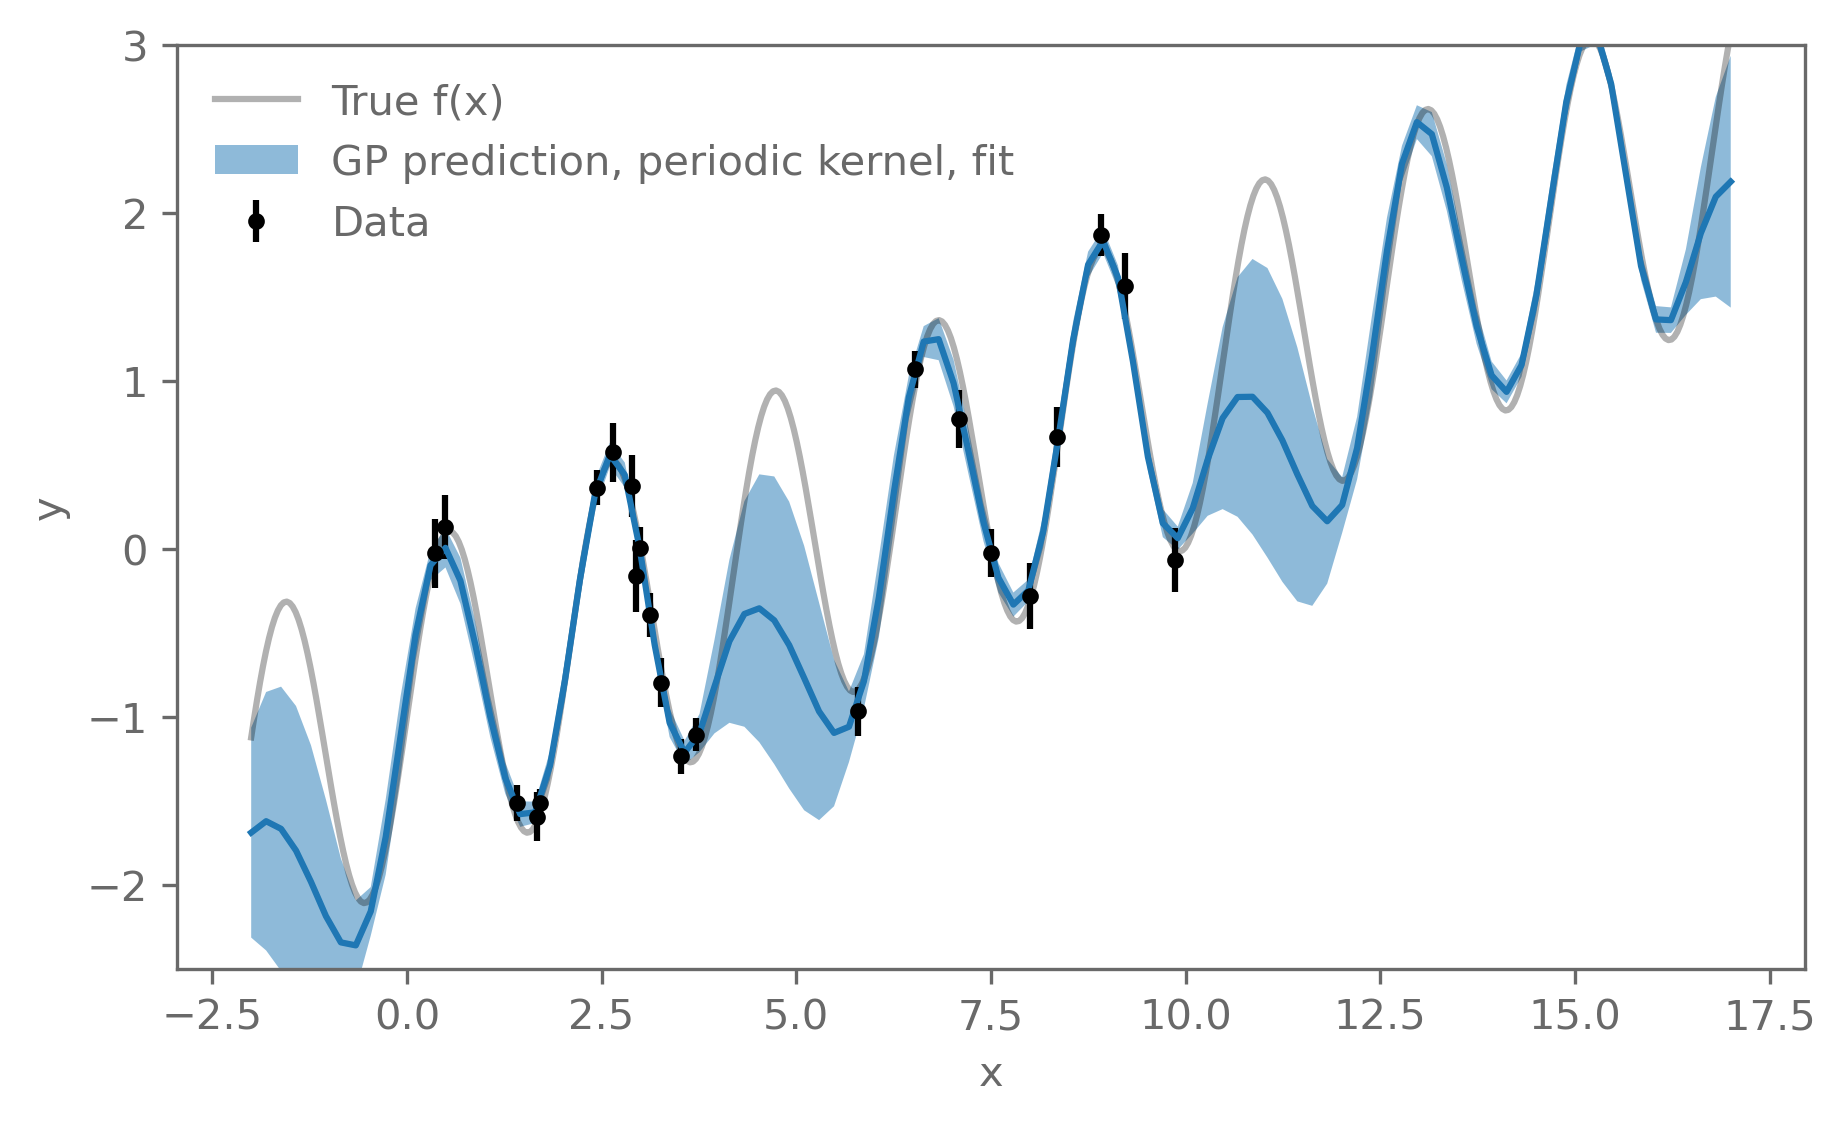

In [33]:
gp = build_gp(soln.params, x_obs=x_obs, y_err=y_err)

conditioned_gp = gp.condition(y=y_obs, X_test=x_pred).gp
mu, std = conditioned_gp.loc, jnp.sqrt(conditioned_gp.variance)

fig, ax = plot_data(x_obs, y_obs, y_err, plot_f_true=True)

ax.plot(x_pred, mu)
ax.fill_between(x_pred, mu-std, mu+std, alpha=0.5, label="GP prediction, periodic kernel, fit")
ax.legend();

### Caveats to keep in mind

Evaluating the Gaussian process likelihood and conditioning both depend on the inverse of the covariance matrix at the position of the observations $\Sigma_{xx}$. 

For $n$ observations, this is a $n\times n$ matrix, which takes $\mathcal{O}(n^3)$ operations to invert. For large $n$, this becomes slow quickly. 

Finding approximate methods that get around this $n^3$ scaling is a big field of research.


Because Gaussian process models are so flexible, we need to be careful with parameter degeneracies. https://betanalpha.github.io/assets/case_studies/gaussian_processes.html#3_Inferring_A_Gaussian_Process has a very insightful description of a pathological (but not unrealistic) example and how to address it.

The take-away message is that the data need to be able to constrain the parameters of the Gaussian process, otherwise issues can arise.
For example, the data can only inform the length scale in a kernel for scales larger than the smallest separation between data points and on scales smaller than the largest separation.

Use of appropriate priors can avoid the optimisation or sampling algorithms getting stuck in degenerate parts of the parameter space.

## Probabilistic programming

The proper way is of course to sample the parameters of the kernel, instead of just finding the best-fit values by maximising the likelihood.

We will do that using `numpyro`, a probabilistic programming framework built on `JAX`.

In probabilistic programming, variables our programs are random variable. 
We specify their distributions and the probabilistic programming framework takes care of propagating the distributions.

This will be a very brief introduction. For a slightly more detailed introduction, have a look at https://dfm.io/posts/intro-to-numpyro/.

To illustrate how this works, we first revisit the linear-fit data set with homoscedastic errors in `data/linear_fits/data_0.txt`.

We assume a Gaussian likelihood with $\mu(x) = m x + b$ and uncertainty $\sigma_y$:
$$
    y_i \sim \Norm(\mu(x_i), \sigma_y^2) \,.
$$

The parameters $m$ and $b$ both have Gaussian priors:
$$
    p(m) = \Norm(1, 1) \\
    p(b) = \Norm(0, 1.2^2)
$$

Our probabilistic model is then
\begin{align}
    m &\sim \Norm(1, 1) \\
    b &\sim \Norm(0, 1.2^2) \\
    y_i &\sim \Norm(m x_i + b, \sigma_y^2)
\end{align}

In probabilistic programming frameworks we can specify such a model and then condition it on the actual observed data $y^\mathrm{obs}_i$.


Instead of writing down (log) probability functions for the priors and likelihood to sample from the posterior, we can write down the model just in terms of its random variables, their distributions, and how they are related, and the probabilistic programming framework takes care of tracking all the probabilities.

In [34]:
x_obs, y_obs, y_err = np.loadtxt("data/linear_fits/data_0.txt", unpack=True)
# For now, all errors are the same
sigma_y = y_err[0]

def plot_linear_data_set(x, y, y_err=None):
    """Plot linear data set and format the plot."""
    fig, ax = plt.subplots(1, 1)

    if y_err is not None:
        ax.errorbar(x, y, y_err, fmt=".", label="Data")
    else:
        ax.plot(x, y, marker=".", linestyle="none", label="Data")

    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.legend(loc="upper left")

    return fig, ax

In [35]:
import numpyro
import numpyro.distributions as distr

# Our probabilistic model needs to be defined as a function
def model(y_obs=None):
    # The parameters are drawn from the prior distributions
    m = numpyro.sample("m", distr.Normal(loc=1, scale=1))
    b = numpyro.sample("b", distr.Normal(loc=0, scale=1.2))

    # We save the mean predictions using the numpyro.deterministic primitive
    mu = numpyro.deterministic("mu", m*x_obs + b)

    # At the end we draw the observations and condition them on the actual
    # observed data
    numpyro.sample("obs", distr.Normal(loc=mu, scale=sigma_y), obs=y_obs)

Once we have the model specified, we can create samples from the prior predictive distribution.

In [36]:
master_key = jax.random.PRNGKey(42)
rng_key, master_key = jax.random.split(master_key)

prior_predictive = numpyro.infer.Predictive(model=model, num_samples=10)
prior_predictive_samples = prior_predictive(rng_key=rng_key)["obs"]

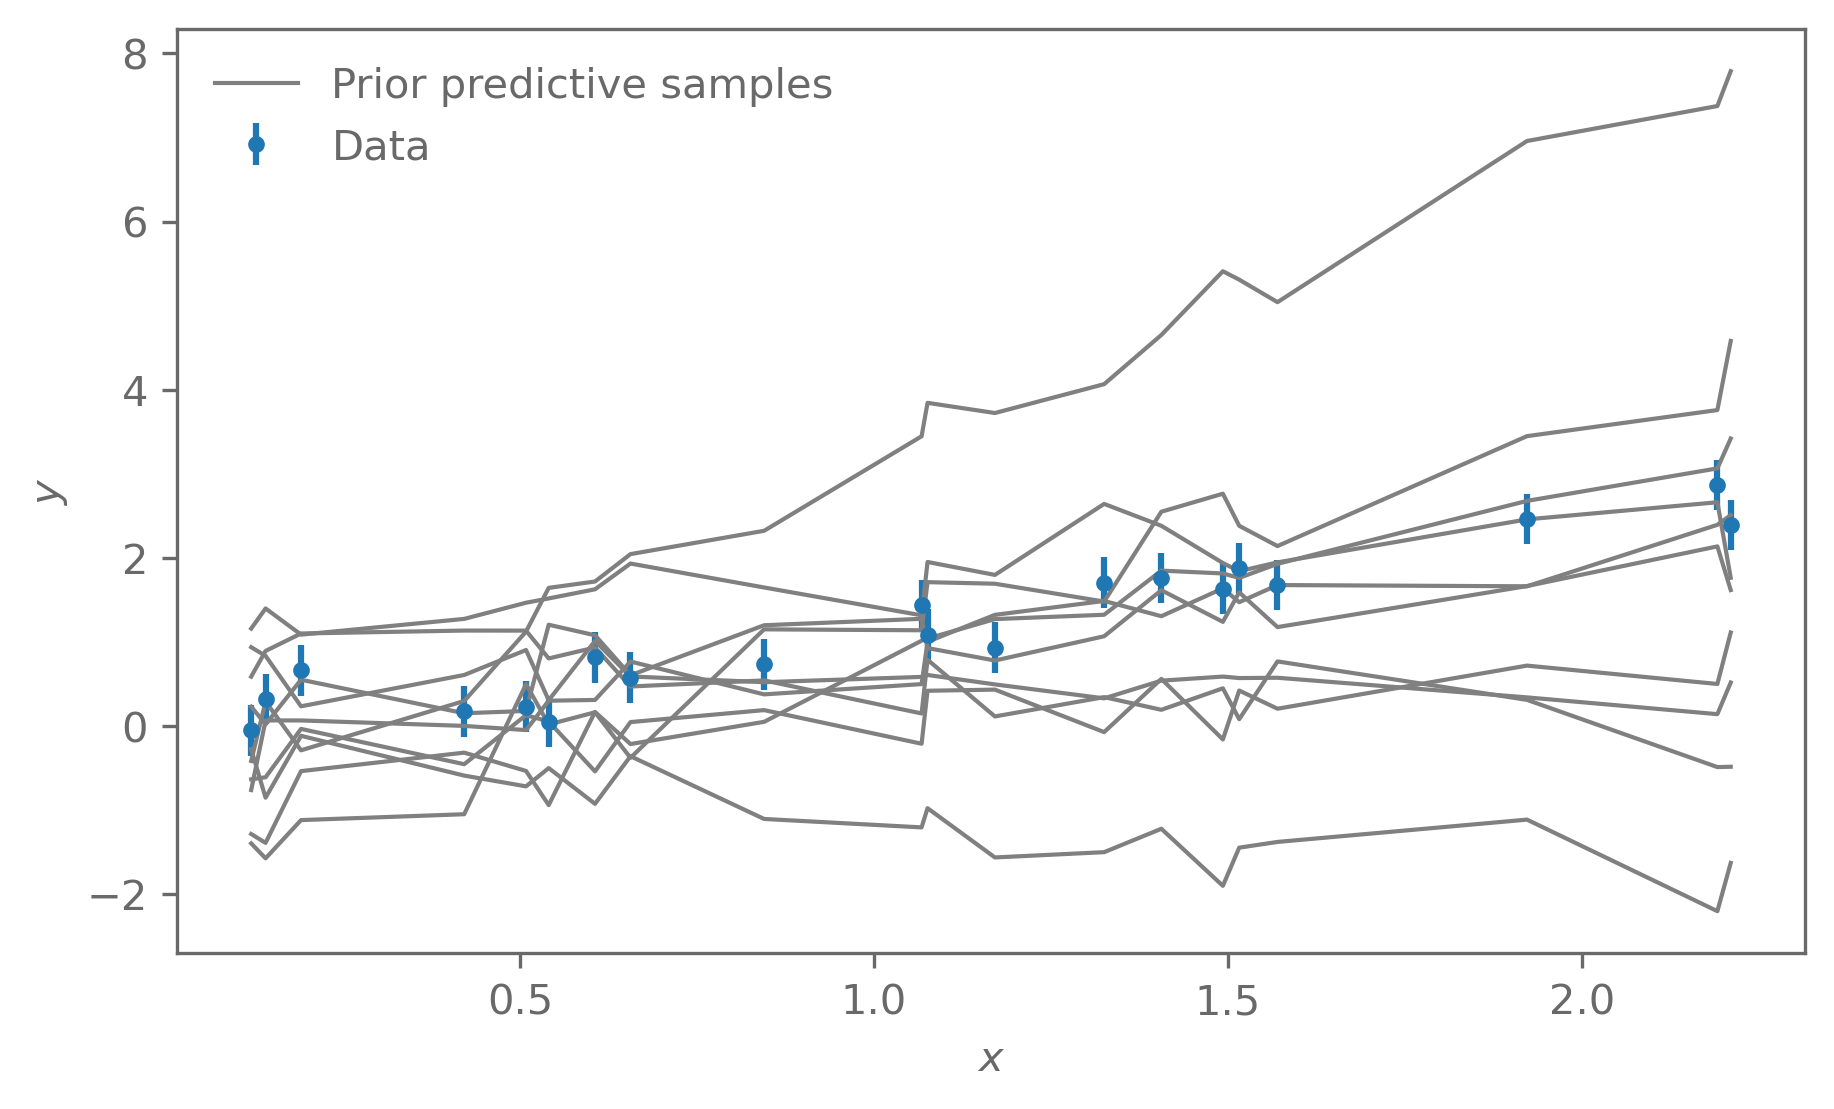

In [41]:
fig, ax = plot_linear_data_set(x_obs, y_obs, y_err)
ax.plot(x_obs, prior_predictive_samples.T, c="grey", lw=1)
ax.plot([], [], c="grey", lw=1, label="Prior predictive samples")
ax.legend();

To get the posterior, we can use the build in NUTS HMC sampler.

In [42]:
rng_key, master_key = jax.random.split(master_key)

# Run NUTS
kernel = numpyro.infer.NUTS(model)
num_samples = 2000
mcmc = numpyro.infer.MCMC(kernel, num_warmup=1000, num_samples=num_samples)
mcmc.run(
    rng_key, y_obs=y_obs
)
mcmc.print_summary()
samples = mcmc.get_samples()

sample: 100%|██████████| 3000/3000 [00:01<00:00, 2911.76it/s, 3 steps of size 3.43e-01. acc. prob=0.94] 



                mean       std    median      5.0%     95.0%     n_eff     r_hat
         b     -0.15      0.13     -0.15     -0.37      0.05    569.90      1.00
         m      1.26      0.10      1.25      1.08      1.42    594.25      1.00

Number of divergences: 0


From here we can look at the posterior samples, or get the posterior predictive distribution:

In [44]:
rng_key, master_key = jax.random.split(master_key)

posterior_predictive = numpyro.infer.Predictive(model=model, posterior_samples=samples)
posterior_predictive_samples = posterior_predictive(rng_key=rng_key)["obs"]

model_predictive_samples = samples["mu"]

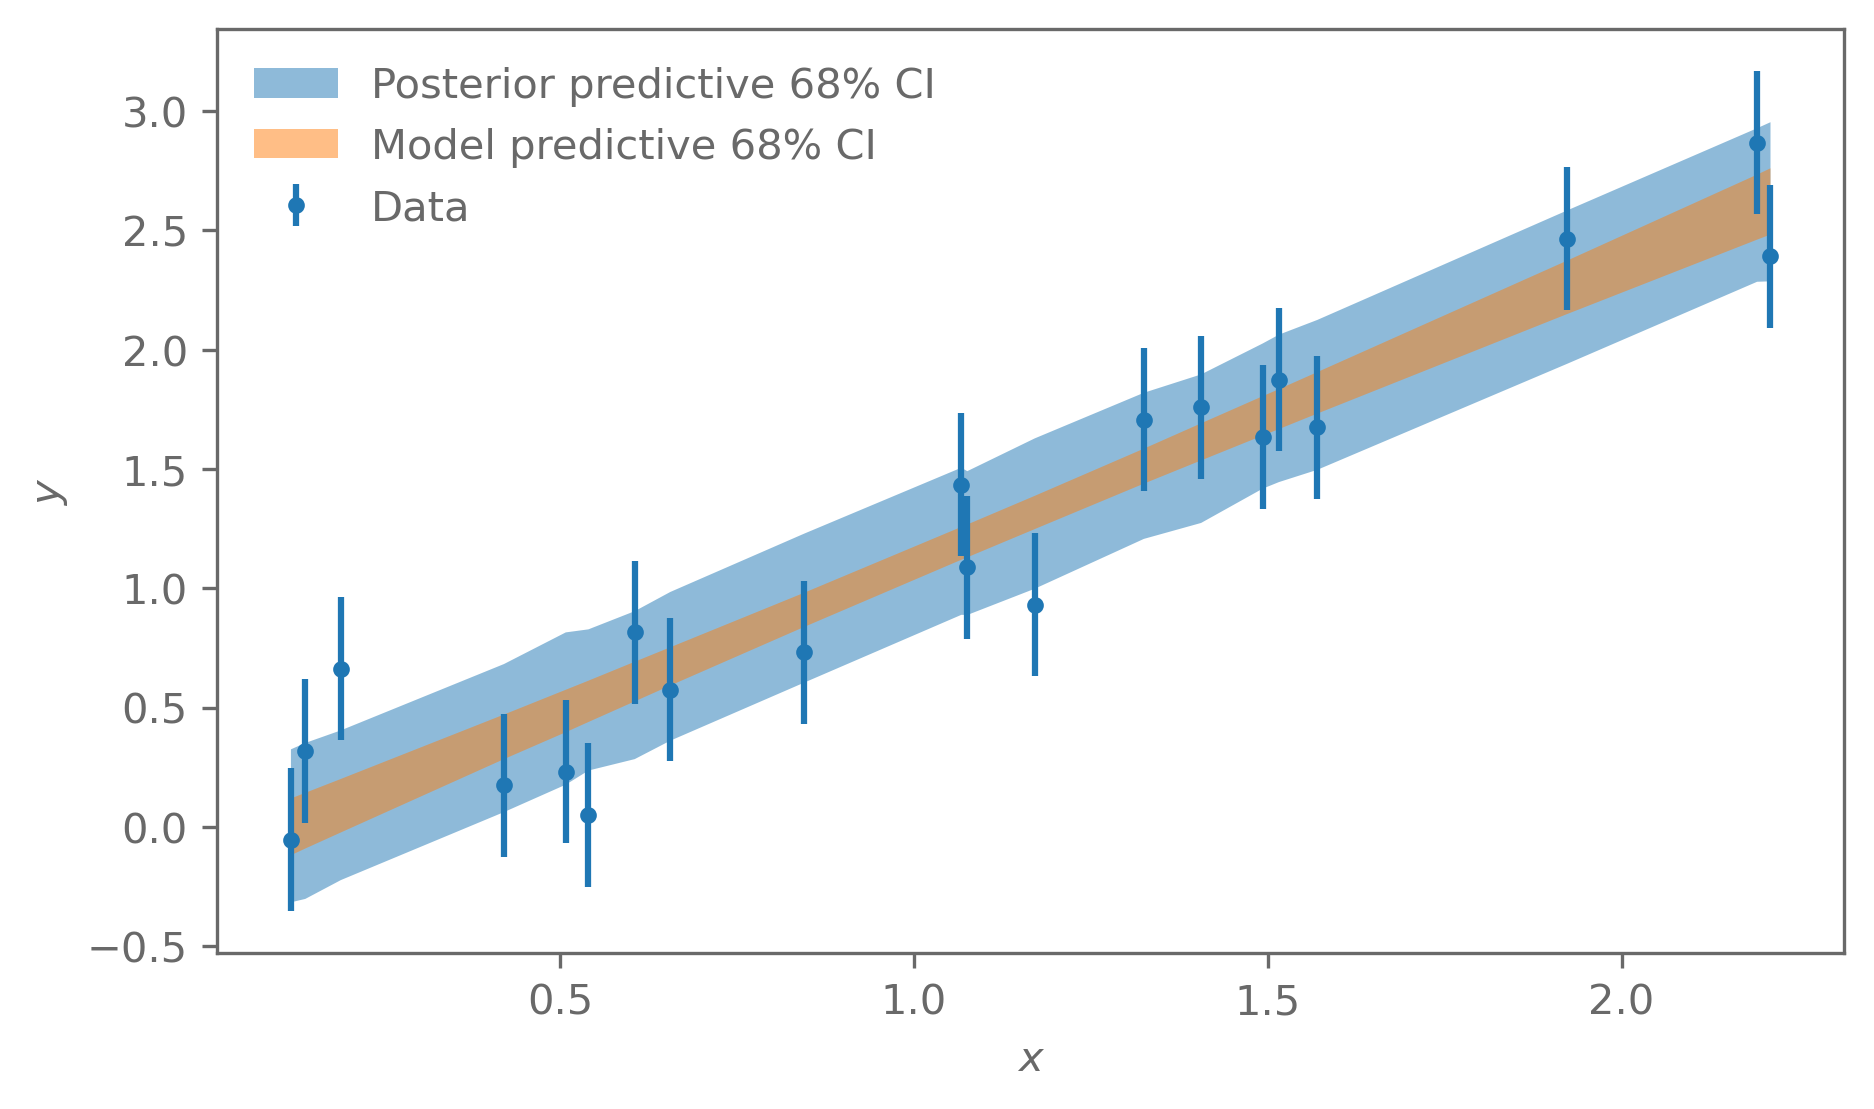

In [45]:
fig, ax = plot_linear_data_set(x_obs, y_obs, y_err)

ax.fill_between(x_obs, *np.quantile(posterior_predictive_samples, [0.16, 0.84], axis=0), alpha=0.5, label="Posterior predictive 68% CI")
ax.fill_between(x_obs, *np.quantile(model_predictive_samples, [0.16, 0.84], axis=0), alpha=0.5, label="Model predictive 68% CI")
ax.legend();

Now that we have seen how to use `numpyro` on this simple example, we can use it to sample the parameters of the Gaussian process:

In [54]:
x_obs, y_obs, y_err = generate_data()

In [55]:
def model(y_obs=None):
    # We need to define priors for our parameters
    period = numpyro.sample("period", distr.Uniform(low=0.1, high=8.0))
    gamma = numpyro.sample("gamma", distr.HalfNormal(scale=10))
    sigma = numpyro.sample("sigma", distr.HalfNormal(scale=10))
    slope = numpyro.sample("slope", distr.Uniform(low=-1, high=1))
    mean = numpyro.sample("mean", distr.Normal(loc=0, scale=1))

    kernel = sigma**2 * tinygp.kernels.ExpSineSquared(scale=period, gamma=gamma) 
    mean_func = lambda x: mean + slope*x

    gp = tinygp.GaussianProcess(kernel, x_obs, diag=sigma_y**2, mean=mean_func)
    # The likelihood is Gaussian, so we can use the distribution of the GP
    # directly
    numpyro.sample("obs", gp.numpyro_dist(), obs=y_obs)

    if y_obs is not None:
        conditioned_gp = gp.condition(y=y_obs, X_test=x_pred).gp
        numpyro.deterministic("pred_mean", conditioned_gp.loc)


In [61]:
# Sample over the model
nuts_kernel = numpyro.infer.NUTS(model, target_accept_prob=0.9)
mcmc = numpyro.infer.MCMC(
    nuts_kernel,
    num_warmup=1000,
    num_samples=1000,
    progress_bar=True,
)
rng_key = jax.random.PRNGKey(55873)
mcmc.run(rng_key, y_obs=y_obs)
samples = mcmc.get_samples()
mcmc.print_summary()

sample: 100%|██████████| 2000/2000 [00:02<00:00, 899.05it/s, 7 steps of size 3.25e-01. acc. prob=0.92]  



                mean       std    median      5.0%     95.0%     n_eff     r_hat
     gamma      0.67      0.88      0.35      0.00      1.69    659.58      1.00
      mean     -0.34      0.83     -0.39     -1.63      1.03    746.80      1.00
    period      2.10      0.03      2.10      2.06      2.15    658.48      1.00
     sigma      2.43      2.20      1.76      0.42      4.76    406.14      1.00
     slope      0.20      0.02      0.20      0.16      0.23    644.55      1.00

Number of divergences: 0


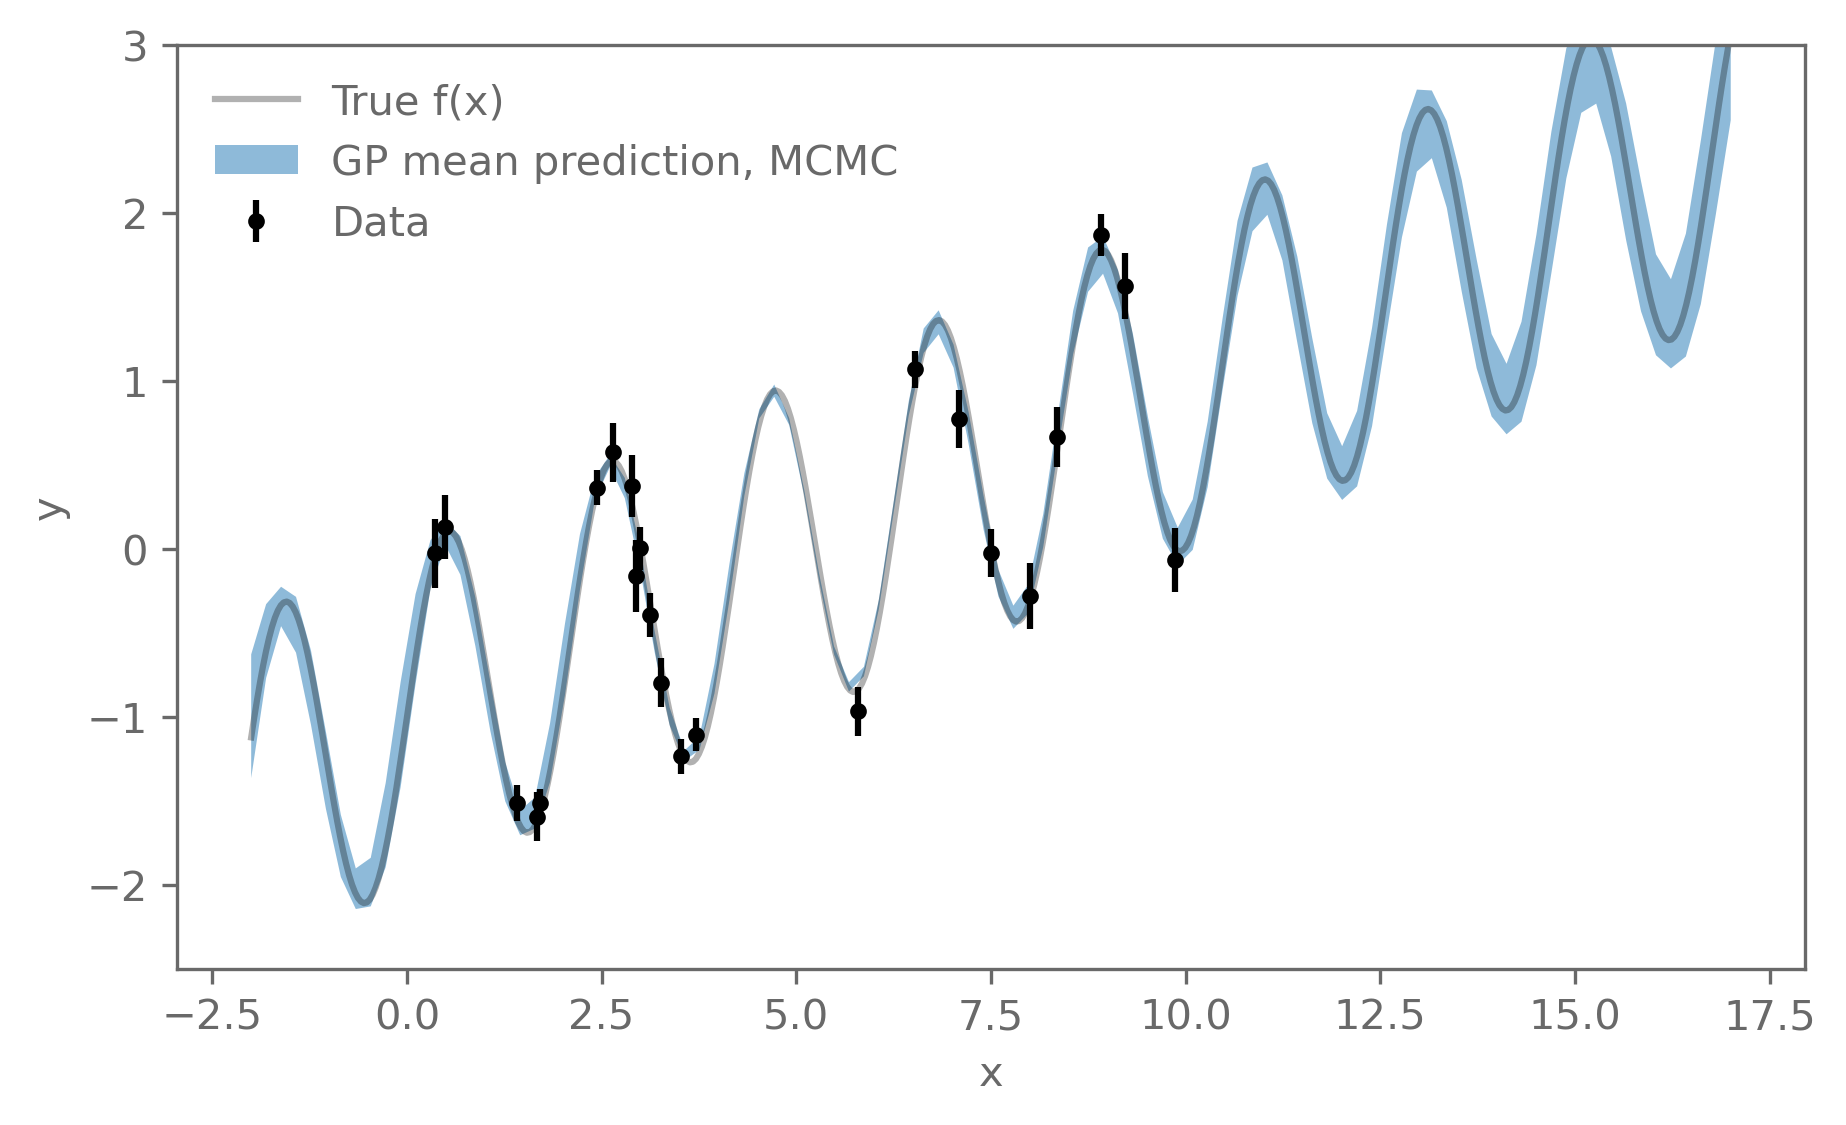

In [62]:
fig, ax = plot_data(x_obs, y_obs, y_err, plot_f_true=True)

ax.fill_between(x_pred, *np.quantile(samples["pred_mean"], [0.16, 0.84], axis=0), alpha=0.5, label="GP mean prediction, MCMC")
ax.legend();

This now accounts for the uncertainty in the kernel (and mean) parameters.

Beside getting this extra uncertainty quantification, this setup also allows us to use a different likelihood.



For example, our data could be photon counts, in which case a Poisson likelihood would be appropriate.

In this example, the Gaussian process model could predict the rate of the Poisson distribution.

In [ ]:
def model(y_obs=None):
    # ...
    # same setup as before

    gp = tinygp.GaussianProcess(kernel, x_obs, diag=1e-3, mean=mean_func)
    log_rate = numpyro.sample("log_rate", gp.numpyro_dist())

    # We now use a Poisson distribution for the likelihood
    numpyro.sample("obs", distr.Poisson(rate=jnp.exp(log_rate)), obs=y_obs)

Note that for a non-Gaussian likelihood, the posterior over the functions is not Gaussian any more, and the exact conditioning does not apply.